# BBVA Data Challenge 2023

## Descripción General de los conjuntos de datos disponibles.
Debido a la alta dimensionalidad procedo a realizar la lectura y primera exploración de los archivos utilizando la librería ***DuckDB*** la cual permite consultar grandes volúmenes de datos de manera eficiente sin necesidad de cargarlos completamente en memoria.

In [4]:
# @title Descargar datos de Drive al entorno
from pathlib import Path
import zipfile

ZIP1 = "/content/drive/MyDrive/BBVA Data Challenge/datos.zip"
ZIP2 = "/content/drive/MyDrive/BBVA Data Challenge/digital.csv.zip"

TEMP_DIR = Path("/content/data")
TEMP_DIR.mkdir(exist_ok=True)

with zipfile.ZipFile(ZIP1, "r") as z:
  z.extractall(TEMP_DIR)

with zipfile.ZipFile(ZIP2, "r") as z:
  z.extractall(TEMP_DIR)

print("...Completado :)")

...Completado :)


In [6]:
import duckdb
con = duckdb.connect("/content/bbva.duckdb")

In [9]:
csv_files = sorted(TEMP_DIR.glob("*.csv"))
print(f"Se encontraron {len(csv_files)} archivos CSV.\n")

for csv_file in csv_files:
  table_name = csv_file.stem
  print(f"Creando tabla '{table_name}'...")

  con.execute(f"""
    CREATE OR REPLACE TABLE {table_name} AS
    SELECT *
    FROM read_csv_auto('{csv_file}');
  """)

print("\nProceso finalizado.")

Se encontraron 8 archivos CSV.

Creando tabla 'balances'...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Creando tabla 'customers'...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Creando tabla 'digital'...


...

Creando tabla 'liabilities'...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Creando tabla 'movements'...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Creando tabla 'sample_submission'...
Creando tabla 'universe_test'...
Creando tabla 'universe_train'...

Proceso finalizado.


In [10]:
# Una vez crada la bas de datos podemos empezar a explorar
con.sql("SHOW TABLES;")

┌───────────────────┐
│       name        │
│      varchar      │
├───────────────────┤
│ balances          │
│ customers         │
│ digital           │
│ liabilities       │
│ movements         │
│ sample_submission │
│ universe_test     │
│ universe_train    │
└───────────────────┘

In [11]:
for tabla in con.sql("SHOW TABLES").fetchall():
    nombre = tabla[0]
    n = con.sql(f"SELECT COUNT(*) FROM {nombre}").fetchone()[0]
    print(f"{nombre:<20} {n:,} filas")

balances             11,597,785 filas
customers            809,579 filas
digital              6,379,650 filas
liabilities          8,876,560 filas
movements            3,697,738 filas
sample_submission    273,636 filas
universe_test        273,636 filas
universe_train       535,943 filas


In [20]:
from IPython.display import display

for tabla in con.sql("SHOW TABLES").fetchall():
    nombre = tabla[0]

    print("="*60)
    print(nombre)
    print(con.sql(f"DESCRIBE {nombre}").df())
    display(con.sql(f"SELECT * FROM {nombre} LIMIT 5").df())
    print("\n")

balances
      column_name column_type null   key default extra
0           month      BIGINT  YES  None    None  None
1              ID     VARCHAR  YES  None    None  None
2            type     VARCHAR  YES  None    None  None
3         product     VARCHAR  YES  None    None  None
4          entity     VARCHAR  YES  None    None  None
5  balance_amount      DOUBLE  YES  None    None  None
6    days_default      DOUBLE  YES  None    None  None
7          period     VARCHAR  YES  None    None  None


,month,ID,type,product,entity,balance_amount,days_default,period
0,11,c844ef92b32ec94baaf565a3d22cfa20fd1544a0f8efab...,type_7,product_2,entity_2,3.4051,5.0,period_5
1,10,c817cb3a37a6b640304e87fafd7cd8569bfffb650a5aa3...,type_7,product_2,entity_1,3.4003,5.0,period_5
2,6,1d1f726d844c5a343cca1bbfd0c2b869559f5910772c5e...,type_7,product_2,entity_5,3.0592,5.0,period_5
3,6,7c77a3fd230db16988cb2e6ca23779c756f86895dfe254...,type_7,product_2,entity_2,2.8013,5.0,period_5
4,11,a8702fb4fbdcb735619d6fbd0a5fed46096cdaba80ea35...,type_7,product_2,entity_2,2.9850,5.0,period_5




customers
              column_name column_type null   key default extra
0                      ID     VARCHAR  YES  None    None  None
1                     age      DOUBLE  YES  None    None  None
2                  income      DOUBLE  YES  None    None  None
3   time_from_specialized      DOUBLE  YES  None    None  None
4                type_job     VARCHAR  YES  None    None  None
5             bureau_risk     VARCHAR  YES  None    None  None
6                 payroll      DOUBLE  YES  None    None  None
7               product_1     BOOLEAN  YES  None    None  None
8               product_2     BOOLEAN  YES  None    None  None
9               product_3     BOOLEAN  YES  None    None  None
10              product_4     BOOLEAN  YES  None    None  None
11                ofert_1     BOOLEAN  YES  None    None  None
12                ofert_2     BOOLEAN  YES  None    None  None
13                ofert_3     BOOLEAN  YES  None    None  None


,ID,age,income,time_from_specialized,type_job,bureau_risk,payroll,product_1,product_2,product_3,product_4,ofert_1,ofert_2,ofert_3
0,42af3bf64c2c14307361e970e76c9653df78b215838971...,4.2484,4.1259,0.0,type_2,category_4,4.8095,True,False,False,True,False,False,False
1,5ab9acd6dc30e0e9361ca53e797b40f68841bd698d0926...,4.6903,3.9570,0.0,type_7,category_9,0.0000,False,False,False,True,False,False,False
2,8e40f988dd93417a0a40c32e65386425d891c879fedf4c...,4.1682,4.4640,0.0,type_7,category_5,0.0000,False,False,False,True,False,False,False
3,0e48974ce6e81d9e81a8da780521a2f98fb2385dc879df...,3.9651,4.0966,0.0,type_7,category_3,0.0000,True,True,True,True,False,False,False
4,e033c53b4fb230de5da6868503a9e079b289e064d62de4...,3.9576,4.1876,0.0,type_7,category_5,0.0000,True,False,False,True,False,False,False




digital
   column_name column_type null   key default extra
0        month      BIGINT  YES  None    None  None
1           ID     VARCHAR  YES  None    None  None
2        dig_1      DOUBLE  YES  None    None  None
3        dig_2      DOUBLE  YES  None    None  None
4        dig_3      DOUBLE  YES  None    None  None
5        dig_4      DOUBLE  YES  None    None  None
6        dig_5      DOUBLE  YES  None    None  None
7        dig_6      DOUBLE  YES  None    None  None
8        dig_7      DOUBLE  YES  None    None  None
9        dig_8      DOUBLE  YES  None    None  None
10       dig_9      DOUBLE  YES  None    None  None
11      dig_10      DOUBLE  YES  None    None  None
12      dig_11      DOUBLE  YES  None    None  None
13      period     VARCHAR  YES  None    None  None


...

,period,ID,target
0,period_9,20b427c65c62ee0177adfa300bbf9f93ba2e46c86d5bc7...,0
1,period_9,4881d4a2146002a02279bedb6f0a844af022b4dd1d8b1b...,0
2,period_9,28ff12351f215091b54166a09ca44858f3d7f6245f281c...,0
3,period_9,5cd2c0dc92c1c5ffa83a94f15756cef5c58174e9d8c69a...,0
4,period_9,ceebdd2bbaafd83d8c205e8071b79da5338e9db94c9509...,0




universe_test
  column_name column_type null   key default extra
0          ID     VARCHAR  YES  None    None  None
1      period     VARCHAR  YES  None    None  None


,ID,period
0,20b427c65c62ee0177adfa300bbf9f93ba2e46c86d5bc7...,period_9
1,4881d4a2146002a02279bedb6f0a844af022b4dd1d8b1b...,period_9
2,28ff12351f215091b54166a09ca44858f3d7f6245f281c...,period_9
3,5cd2c0dc92c1c5ffa83a94f15756cef5c58174e9d8c69a...,period_9
4,ceebdd2bbaafd83d8c205e8071b79da5338e9db94c9509...,period_9




universe_train
  column_name column_type null   key default extra
0          ID     VARCHAR  YES  None    None  None
1   attrition      BIGINT  YES  None    None  None
2      period     VARCHAR  YES  None    None  None


,ID,attrition,period
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,0,period_5
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,0,period_5
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,0,period_5
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,0,period_5
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,0,period_5


### Revisando Target en Train y la distribución de periodos en Test

In [33]:
con.sql("""
SELECT period, COUNT(period)
FROM universe_train
GROUP BY period,
ORDER BY period""").df()

,period,count(period)
0,period_1,86028
1,period_2,87386
2,period_3,88998
3,period_4,90920
4,period_5,91539
5,period_6,91072


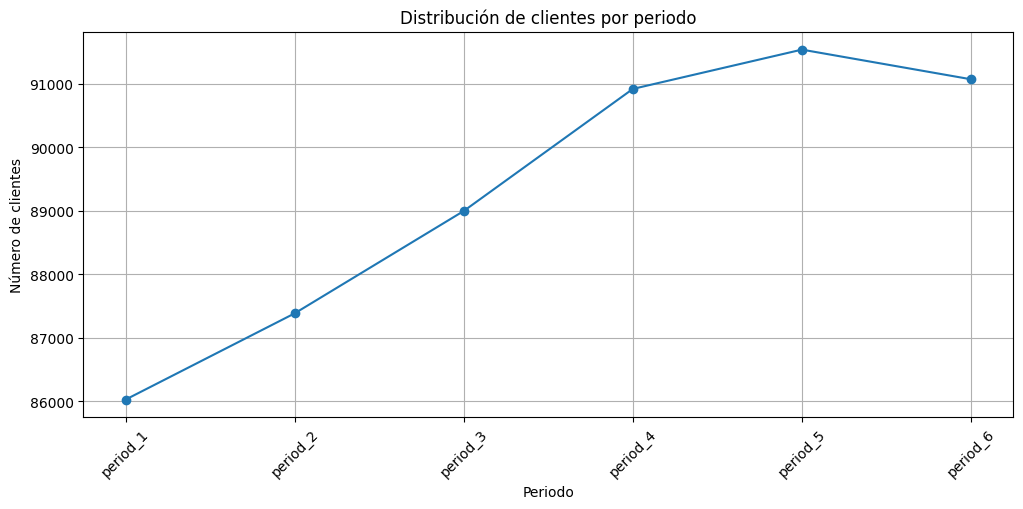

In [35]:
# @title Clientes por periodo en TRAIN
import matplotlib.pyplot as plt

df_period = con.sql("""
SELECT
    period,
    COUNT(*) AS n_clients
FROM universe_train
GROUP BY period
ORDER BY period
""").df()

plt.figure(figsize=(12,5))

plt.plot(
    df_period["period"],
    df_period["n_clients"],
    marker="o"
)

plt.xticks(rotation=45)
plt.xlabel("Periodo")
plt.ylabel("Número de clientes")
plt.title("Distribución de clientes por periodo")

plt.grid(True)
plt.show()

In [41]:
con.sql("""
SELECT
    period,
    attrition,
    COUNT(*) AS n_clients,
    COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(PARTITION BY period) AS percentage
FROM universe_train
GROUP BY period, attrition
ORDER BY period, attrition""").df()

,period,attrition,n_clients,percentage
0,period_1,0,74991,87.170456
1,period_1,1,7329,8.519319
2,period_1,2,872,1.013623
3,period_1,3,512,0.595155
4,period_1,4,1137,1.321663
5,period_1,5,1187,1.379783
6,period_2,0,75824,86.769048
7,period_2,1,7752,8.870986
8,period_2,2,967,1.106585
9,period_2,3,539,0.616804


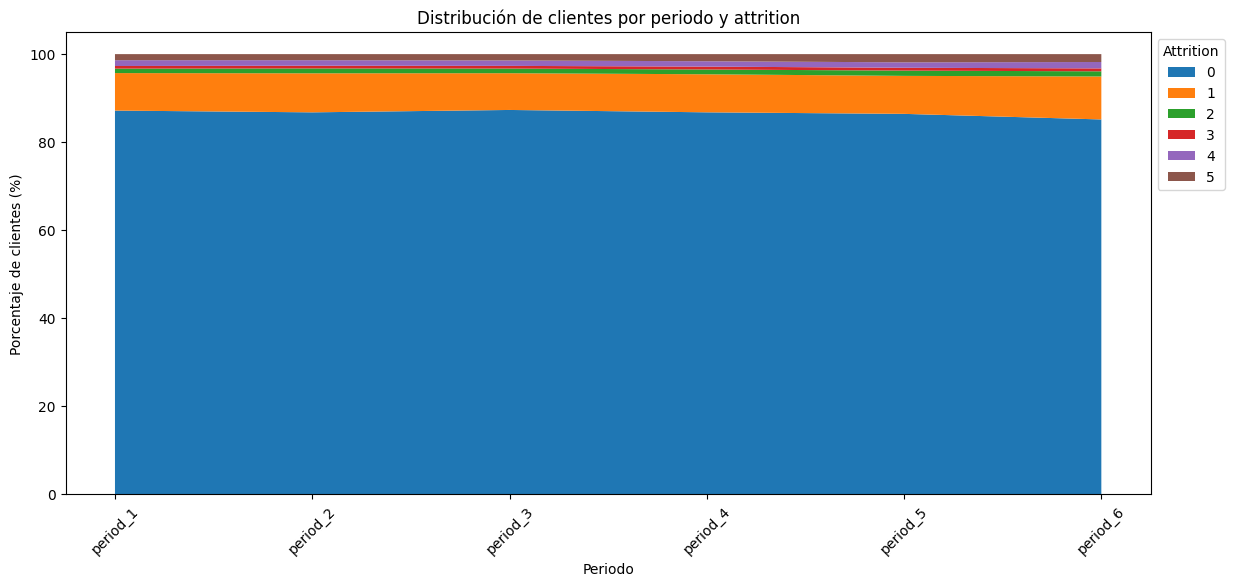

In [40]:
# @title Clientes por periodo y attrition
import matplotlib.pyplot as plt

df_attrition = con.sql("""
SELECT
    period,
    attrition,
    COUNT(*) AS n_clients,
    COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(PARTITION BY period) AS percentage
FROM universe_train
GROUP BY period, attrition
ORDER BY period, attrition
""").df()

pivot = (
    df_attrition
    .pivot(
        index="period",
        columns="attrition",
        values="percentage"
    )
    .fillna(0)
)


plt.figure(figsize=(14,6))

plt.stackplot(
    pivot.index,
    pivot.T,
    labels=pivot.columns
)

plt.xlabel("Periodo")
plt.ylabel("Porcentaje de clientes (%)")
plt.title("Distribución de clientes por periodo y attrition")
plt.legend(title="Attrition", bbox_to_anchor=(1,1))
plt.xticks(rotation=45)

plt.show()

In [32]:
con.sql("""
SELECT period, COUNT(period)
FROM universe_test
GROUP BY period
ORDER BY period""").df()

,period,count(period)
0,period_7,90314
1,period_8,90610
2,period_9,92712


## RESUMEN:
- Existen 8 tablas disponibles, de las cuales la información se encuentra a nivel de:

  ```text
  cliente - periodo.
  ```

  ```text
  cliente - mes - periodo.
  ```

- Las tablas se relacionan tanto por el id del cliente, como por el mes y el periodo.

- Cada fila representa un cliente en un determinado mes de un determinado periodo y su razón de abandono. El valor 0 representa que no hubo abandono, los valores del 1 al 5 representan los motivos de abandono o attrition del cliente.

- Por indicación de la organización, la división no fue aleatoria, fue cronológica.

- También, por indicación de la organización, cada cliente en cada periodo tiene un diferente ID, por lo que no se puede hacer seguimiento de un cliente específico, cada ID es único en la base de datos, por lo tanto, no podemos saber el comportamiento de un clientet a lo largo de los periodos.

- El payroll hace referencia a un ingreso real del cliente proveniente del pago de su sueldo. El income es un ingreso estimado que se calcula con un modelo analítico.

- Hay un desbalance de clases en el target muy grande. Pero la distribucion del target a lo largo de los periodos es casi constante.

### Descripción de los datos

<a href="https://ibb.co/JW23WsMX"><img src="https://i.ibb.co/wZCcZzxD/Captura.png" alt="Descripción de Datos" border="0"></a>

